In [57]:
# Popularity-Based Movie Recommendation System

### Objective
## To build a recommendation system that suggests the most popular movies based on user ratings using the MovieLens 100K dataset.

### Dataset
## MovieLens 100K Dataset

### Developed Using
# Python
# Pandas
# NumPy
# Matplotlib
# Seaborn

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [59]:
# Load Ratings Dataset

rating_columns = ['user_id', 'movie_id', 'rating', 'timestamp']

ratings = pd.read_csv(
    r"D:\AI course\Assignments\Popularity_Recomendation Based System\Data\ml-100k\u.data",
    sep='\t',
    names=rating_columns,
    header=None
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [60]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [61]:
# Load Movies Dataset

movie_columns = [
    'movie_id', 'title', 'release_date', 'video_release_date',
    'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation',
    'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
    'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

movies = pd.read_csv(
    r"D:\AI course\Assignments\Popularity_Recomendation Based System\Data\ml-100k\u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    names=movie_columns
)

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [62]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   IMDb_URL            1679 non-null   object 
 5   unknown             1682 non-null   int64  
 6   Action              1682 non-null   int64  
 7   Adventure           1682 non-null   int64  
 8   Animation           1682 non-null   int64  
 9   Children            1682 non-null   int64  
 10  Comedy              1682 non-null   int64  
 11  Crime               1682 non-null   int64  
 12  Documentary         1682 non-null   int64  
 13  Drama               1682 non-null   int64  
 14  Fantasy             1682 non-null   int64  
 15  Film-Noir           1682 non-null   int64  
 16  Horror

In [63]:
# Check Missing Values

print("Missing Values in Ratings Dataset")
print(ratings.isnull().sum())

print("\nMissing Values in Movies Dataset")
print(movies.isnull().sum())

Missing Values in Ratings Dataset
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing Values in Movies Dataset
movie_id                 0
title                    0
release_date             1
video_release_date    1682
IMDb_URL                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Children                 0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64


In [75]:
movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [76]:
ratings['rating'].value_counts().sort_index()

rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

In [74]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


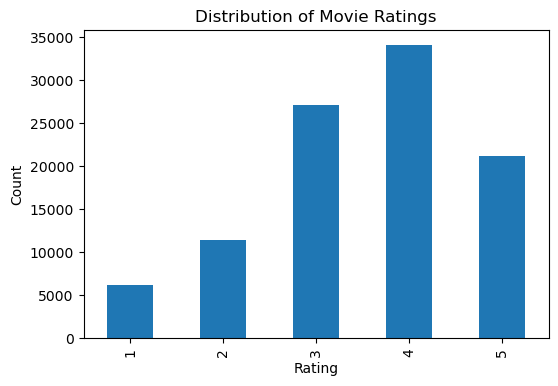

In [77]:
plt.figure(figsize=(6,4))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [64]:
# Merge Ratings and Movies

movie_data = pd.merge(ratings, movies, on='movie_id')

movie_data.head()

,user_id,movie_id,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0


In [65]:
print("Shape of Dataset:", movie_data.shape)

movie_data.info()

Shape of Dataset: (100000, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             100000 non-null  int64  
 1   movie_id            100000 non-null  int64  
 2   rating              100000 non-null  int64  
 3   timestamp           100000 non-null  int64  
 4   title               100000 non-null  object 
 5   release_date        99991 non-null   object 
 6   video_release_date  0 non-null       float64
 7   IMDb_URL            99987 non-null   object 
 8   unknown             100000 non-null  int64  
 9   Action              100000 non-null  int64  
 10  Adventure           100000 non-null  int64  
 11  Animation           100000 non-null  int64  
 12  Children            100000 non-null  int64  
 13  Comedy              100000 non-null  int64  
 14  Crime               100000 non-null  int64  
 15  Docu

In [66]:
print("Duplicate Rows:", movie_data.duplicated().sum())

Duplicate Rows: 0


In [67]:
movie_rating = movie_data.groupby(
    ['movie_id', 'title']
)['rating'].mean().reset_index()

movie_rating.rename(columns={'rating':'Average_Rating'}, inplace=True)

movie_rating.head()

,movie_id,title,Average_Rating
0,1,Toy Story (1995),3.878319
1,2,GoldenEye (1995),3.206107
2,3,Four Rooms (1995),3.033333
3,4,Get Shorty (1995),3.550239
4,5,Copycat (1995),3.302326


In [68]:
rating_count = movie_data.groupby(
    ['movie_id', 'title']
)['rating'].count().reset_index()

rating_count.rename(columns={'rating':'Rating_Count'}, inplace=True)

rating_count.head()

,movie_id,title,Rating_Count
0,1,Toy Story (1995),452
1,2,GoldenEye (1995),131
2,3,Four Rooms (1995),90
3,4,Get Shorty (1995),209
4,5,Copycat (1995),86


In [69]:
recommendation_data = pd.merge(
    movie_rating,
    rating_count,
    on=['movie_id','title']
)

recommendation_data.head()

,movie_id,title,Average_Rating,Rating_Count
0,1,Toy Story (1995),3.878319,452
1,2,GoldenEye (1995),3.206107,131
2,3,Four Rooms (1995),3.033333,90
3,4,Get Shorty (1995),3.550239,209
4,5,Copycat (1995),3.302326,86


In [70]:
recommendation_data = recommendation_data[
    recommendation_data['Rating_Count'] >= 50
]

recommendation_data.head()

,movie_id,title,Average_Rating,Rating_Count
0,1,Toy Story (1995),3.878319,452
1,2,GoldenEye (1995),3.206107,131
2,3,Four Rooms (1995),3.033333,90
3,4,Get Shorty (1995),3.550239,209
4,5,Copycat (1995),3.302326,86


In [71]:
genre_columns = [
    'Action','Adventure','Animation','Children',
    'Comedy','Crime','Documentary','Drama',
    'Fantasy','Film-Noir','Horror','Musical',
    'Mystery','Romance','Sci-Fi',
    'Thriller','War','Western'
]

recommendation_data = pd.merge(
    recommendation_data,
    movies[['movie_id'] + genre_columns],
    on='movie_id'
)

recommendation_data.head()

,movie_id,title,Average_Rating,Rating_Count,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),3.878319,452,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),3.206107,131,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),3.033333,90,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),3.550239,209,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),3.302326,86,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [72]:
genres = [
    'Action', 'Adventure', 'Animation', 'Children',
    'Comedy', 'Crime', 'Documentary', 'Drama',
    'Fantasy', 'Film-Noir', 'Horror', 'Musical',
    'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]

for genre in genres:
    print("\n" + "="*60)
    print(f"Top 5 {genre} Movies")
    print("="*60)

    genre_movies = recommendation_data[
        recommendation_data[genre] == 1
    ]

    genre_movies = genre_movies.sort_values(
        by=['Average_Rating', 'Rating_Count'],
        ascending=False
    )

    display(
        genre_movies[['title', 'Average_Rating', 'Rating_Count']].head(5)
    )


Top 5 Action Movies


,title,Average_Rating,Rating_Count
38,Star Wars (1977),4.358491,583
102,"Godfather, The (1972)",4.283293,413
145,Raiders of the Lost Ark (1981),4.252381,420
269,Titanic (1997),4.245714,350
143,"Empire Strikes Back, The (1980)",4.204360,367



Top 5 Adventure Movies


,title,Average_Rating,Rating_Count
38,Star Wars (1977),4.358491,583
145,Raiders of the Lost Ark (1981),4.252381,420
402,Lawrence of Arabia (1962),4.231214,173
143,"Empire Strikes Back, The (1980)",4.204360,367
391,"African Queen, The (1951)",4.184211,152



Top 5 Animation Movies


...

,title,Average_Rating,Rating_Count
321,"Close Shave, A (1995)",4.491071,112
448,Rear Window (1954),4.387560,209
10,"Usual Suspects, The (1995)",4.385768,267
404,"Third Man, The (1949)",4.333333,72
81,"Silence of the Lambs, The (1991)",4.289744,390



Top 5 War Movies


,title,Average_Rating,Rating_Count
273,Schindler's List (1993),4.466443,298
376,Casablanca (1942),4.456790,243
38,Star Wars (1977),4.358491,583
367,Dr. Strangelove or: How I Learned to Stop Worr...,4.252577,194
402,Lawrence of Arabia (1962),4.231214,173



Top 5 Western Movies


,title,Average_Rating,Rating_Count
479,High Noon (1952),4.102273,88
344,Butch Cassidy and the Sundance Kid (1969),3.949074,216
401,"Magnificent Seven, The (1954)",3.942149,121
174,Unforgiven (1992),3.868132,182
148,"Good, The Bad and The Ugly, The (1966)",3.861314,137


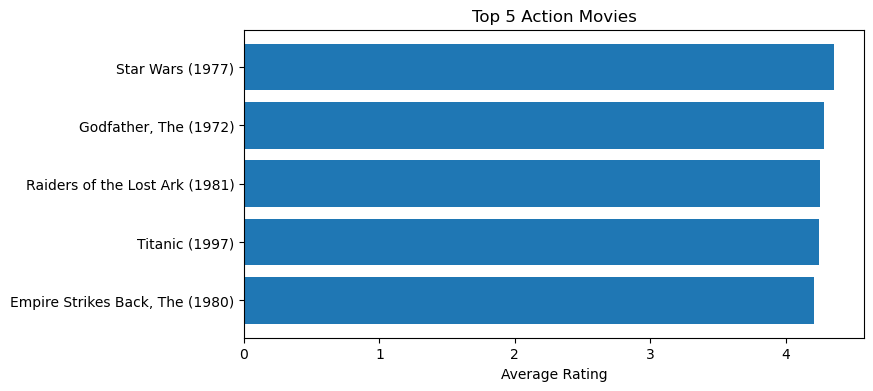

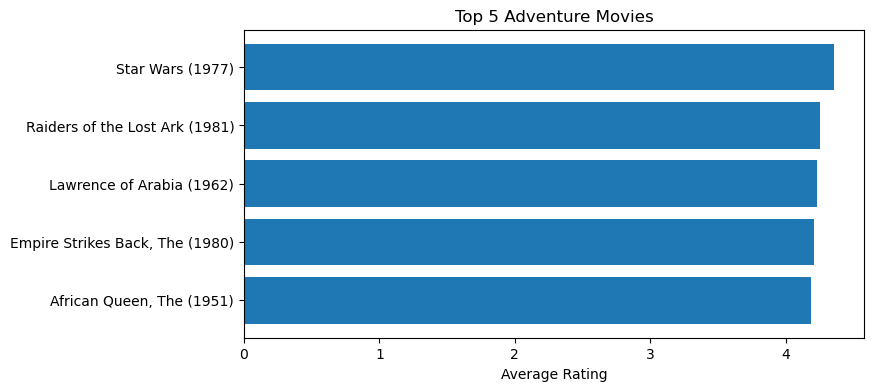

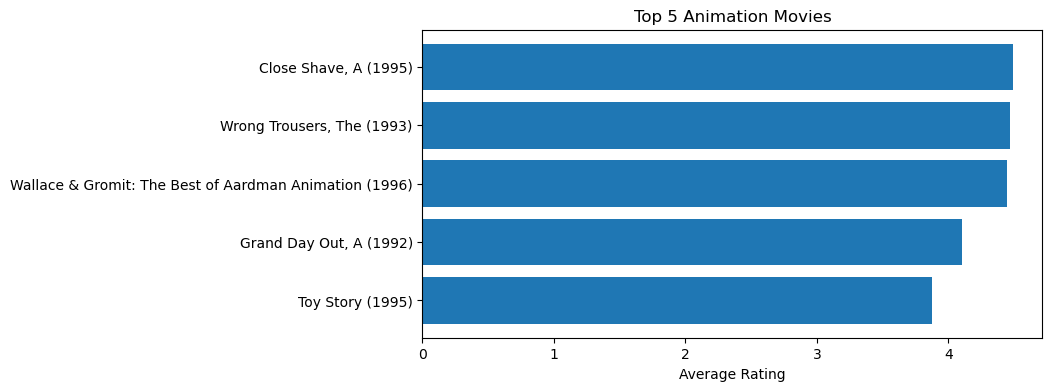

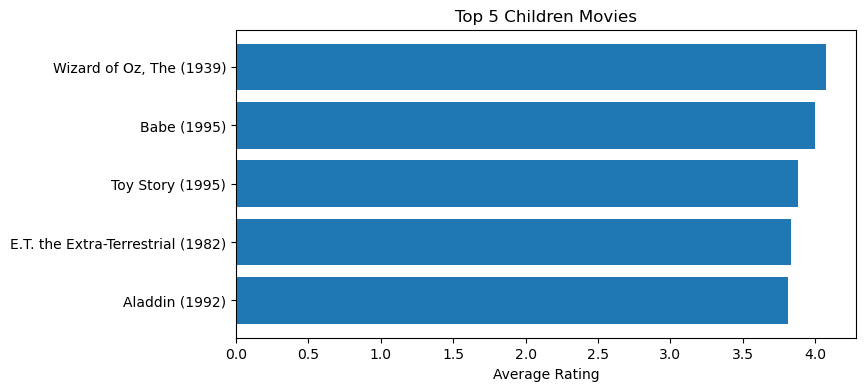

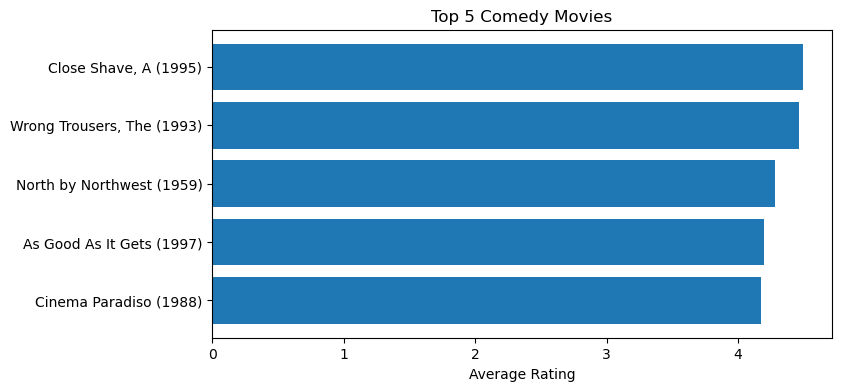

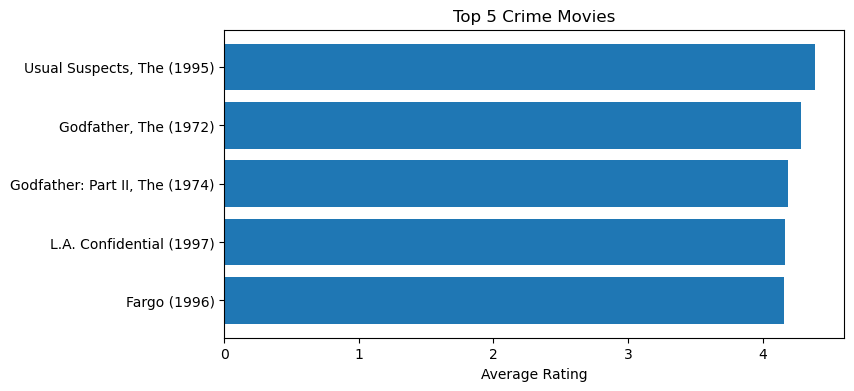

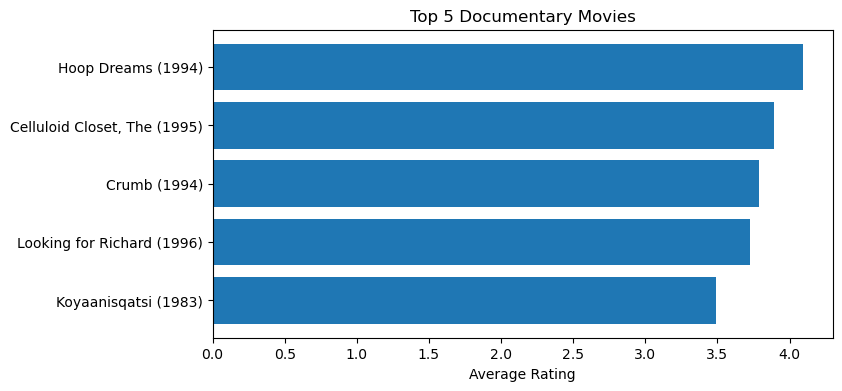

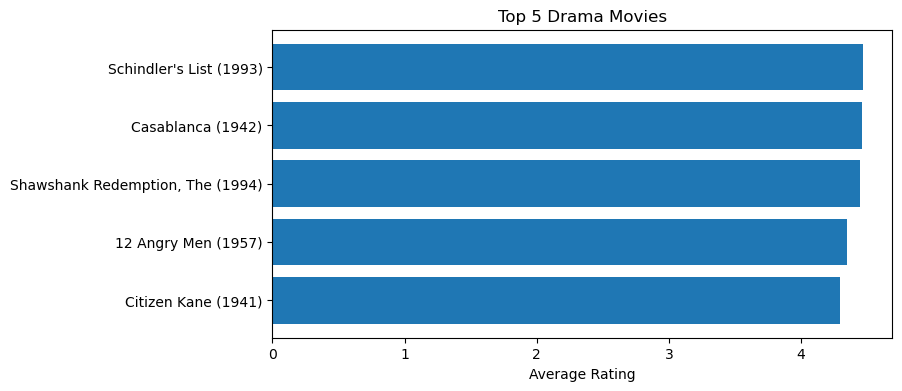

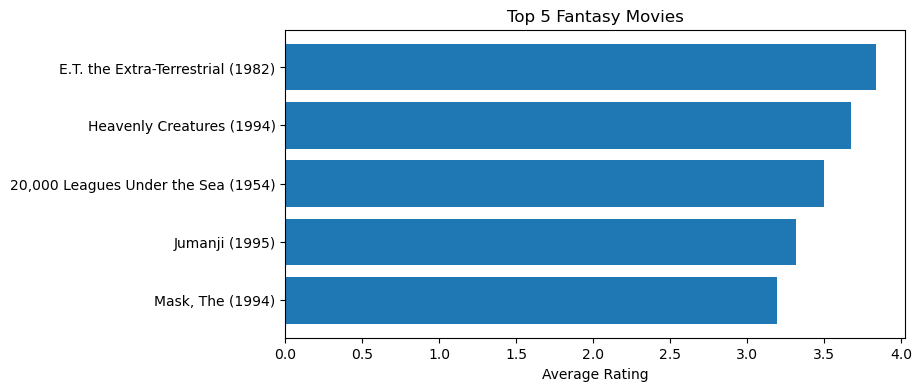

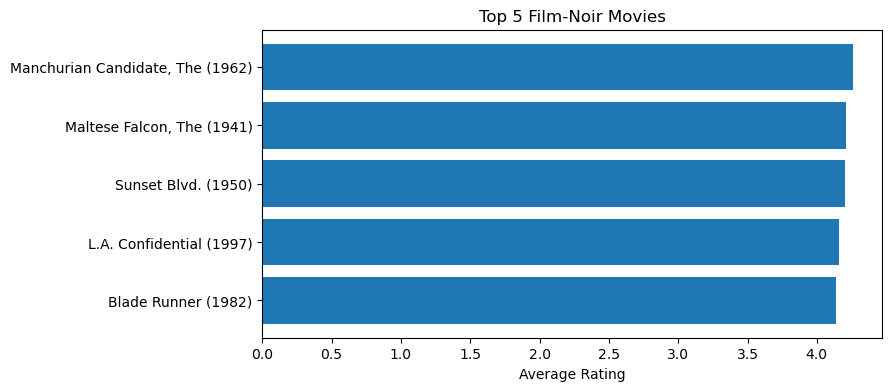

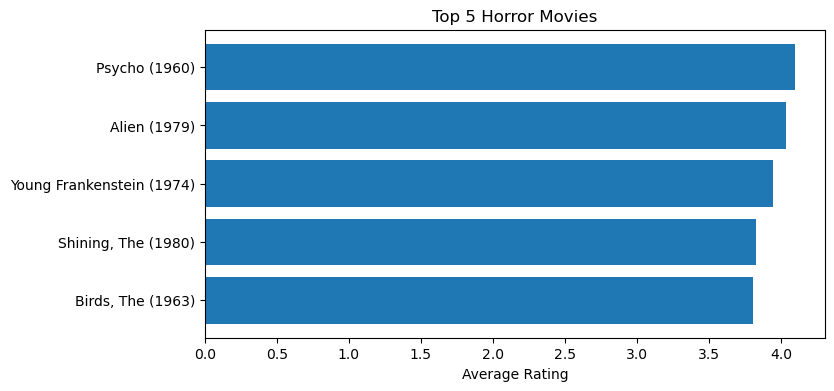

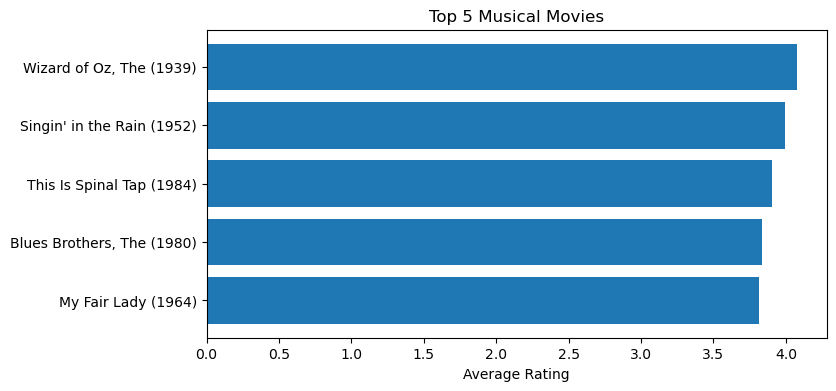

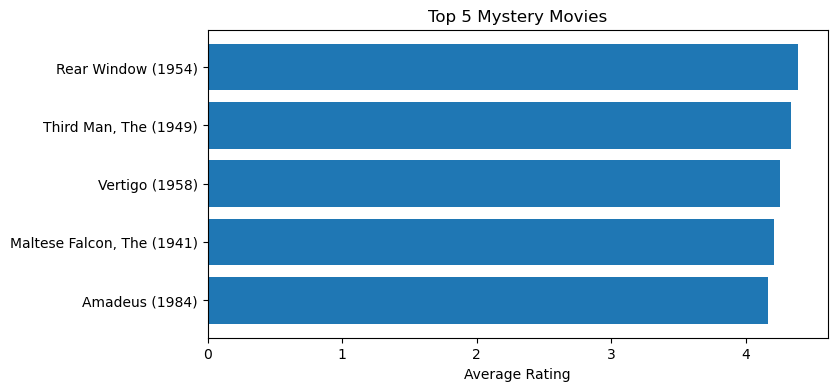

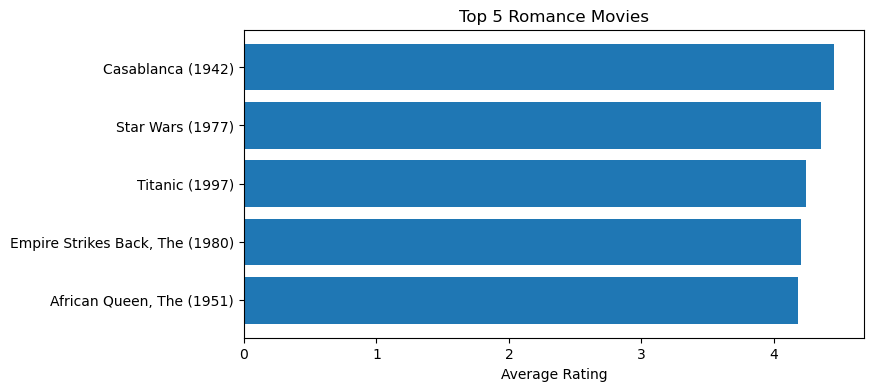

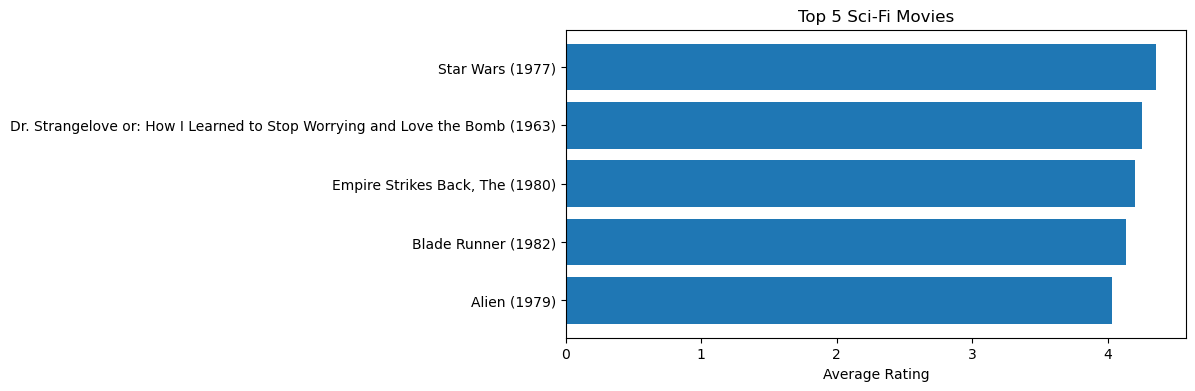

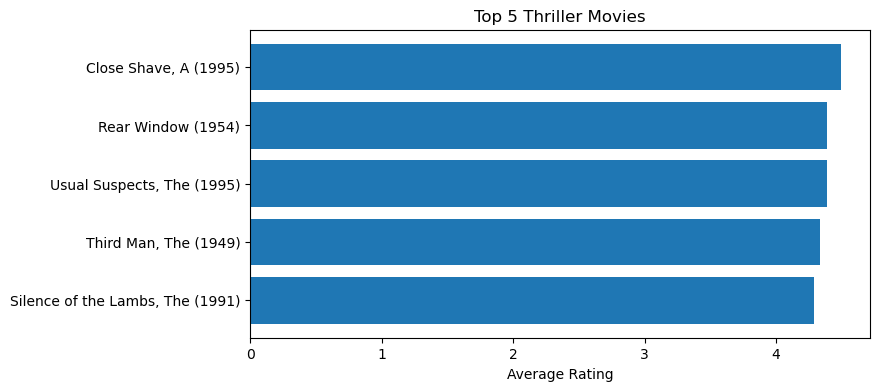

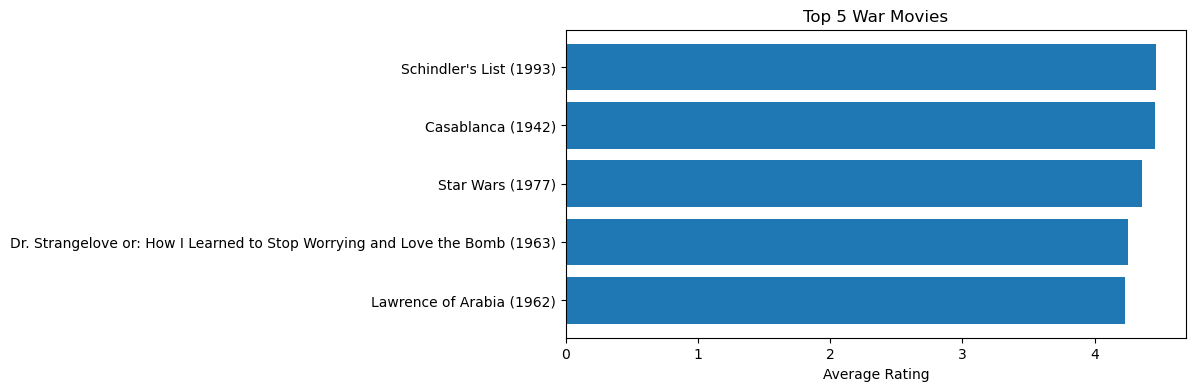

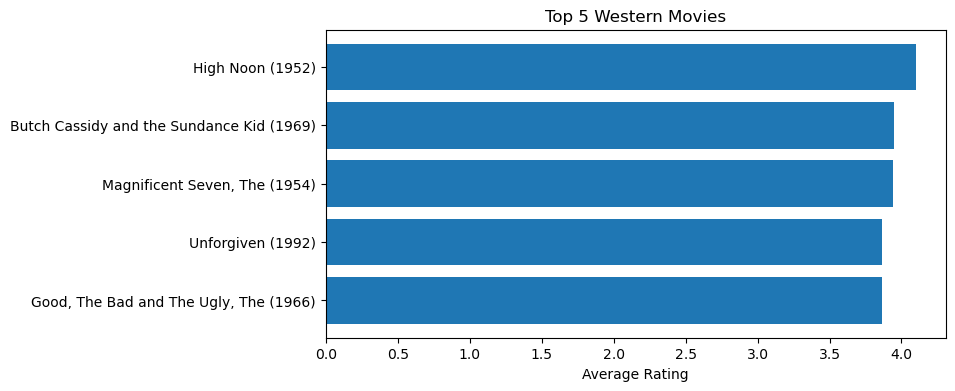

In [73]:
genres = [
    'Action', 'Adventure', 'Animation', 'Children',
    'Comedy', 'Crime', 'Documentary', 'Drama',
    'Fantasy', 'Film-Noir', 'Horror', 'Musical',
    'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]

for genre in genres:

    genre_movies = recommendation_data[
        recommendation_data[genre] == 1
    ].sort_values(
        by=['Average_Rating', 'Rating_Count'],
        ascending=False
    ).head(5)

    plt.figure(figsize=(8,4))
    plt.barh(genre_movies['title'], genre_movies['Average_Rating'])
    plt.title(f"Top 5 {genre} Movies")
    plt.xlabel("Average Rating")
    plt.gca().invert_yaxis()
    plt.show()